<a href="https://colab.research.google.com/github/2403A51355/ml_lab/blob/main/ml_lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv("/content/gender_submission.csv")
df

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [ ]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [ ]:
import numpy as np

In [ ]:
x=np.array(x).reshape(-1,1)
y=np.array(y).reshape(-1,1)

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
)
print("training samples:",x_train.shape)
print("testing samples:",x_test.shape)


training samples: (334, 1)
testing samples: (84, 1)


In [ ]:
from sklearn.svm import SVC

In [ ]:
svm_linear=SVC(kernel="linear",class_weight="balanced",C=0.01)

In [ ]:
svm_linear.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC(C=0.01, class_weight='balanced', kernel='linear')

In [ ]:
y_pred=svm_linear.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score ,confusion_matrix,precision_score,recall_score,f1_score


In [ ]:

accuracy=accuracy_score(y_test,y_pred)
print(accuracy)

0.5238095238095238


In [ ]:
cm = confusion_matrix(y_test, y_pred,labels=[1,0])
print("confusion matrix:")
print("TP FP")
print(" FN TN")
cm

confusion matrix:
TP FP
 FN TN


array([[18, 16],
       [24, 26]])

In [ ]:
precision = precision_score(y_test,y_pred,zero_division=0)
print(precision)

0.42857142857142855


In [ ]:
recall=recall_score(y_test,y_pred,zero_division=0)
print(recall)

0.5294117647058824


In [ ]:
f1=f1_score(y_test,y_pred,zero_division=0)
print(f1)


0.47368421052631576


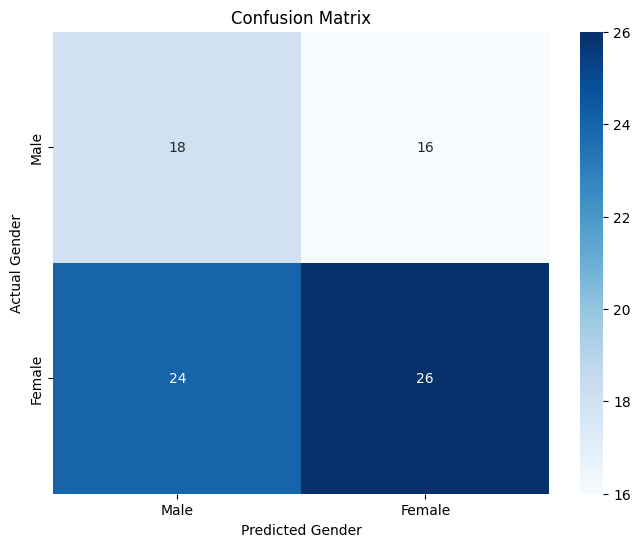

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
cm=confusion_matrix(y_test,y_pred,labels=[1,0])
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['Male','Female'],yticklabels=['Male','Female'])
plt.xlabel('Predicted Gender')
plt.ylabel('Actual Gender')
plt.title('Confusion Matrix')
plt.show()